# TBMI Assignment 5
_Rijcklof Hofman s4792432_

- Add parameter a,b tracking to the notebook (you might want to first only track a/b and then track all parameters or a combination of them)
- Save and track the Kalman correction terms. These act as a forcing term (like a current, except that they act on both x_0 and x_1). Try varying some parameters and observe how they change. What do you conclude? (5 points)
- Another way we are “cheating” is that we give the model system (xhat) the same initial conditions as the real system, and of course in real life we wouldn’t know the latter. Try changing the initial conditions for xhat and see how the model reacts and at which point you break it (5 points)
- Exercise 5.2. This means: change/add code following in ukf_voss.py so that you can do parameter tracking in a Lorenz system in a similar way that the notebook Assignment5_stub.ipynb does.

___Ex5.2___

_Now let’s modify the algorithm from exercise 5.1 to track the Lorenz equations. There are three parameters and three variables to track._

_• Hint: The Lorenz equations are very sensitive to initial conditions and thus round off error. So use a small integration time step—say, 0.001. Run the program for about 10,000 steps. Use the following to help get started:_

_Parameters [10; 46; 8/3]% sigma, r, and b_

_• Try using Q’s of 0.015 like for the Fitzhugh-Nagumo equations. Examine at least the tracking of x and y, as well as the parameters. Can you track well?_

_• Now try using Q’s proportional to the magnitude of the parameters, such as_

_Q1=10_

_Q2=46_

_Q3=8/3_

_Is this better?_

_• If you plot the true x variable against the estimated ˆx, you might get something that looks like figure 5.7 (plate 4), if you have done this well. Note in the figure that I have included the difficulties with the Lorenz z variable—not unexpected [PC90]._

- Modify the provided code so that you can do some parameter search: for example do
a grid search across parameters b and c and explore the parameter space to find the
optimal parameters that minimize chi_squared (plot the chi_squared for the grid search). You will likely have to turn the main estimation loop into a function that you can call with different parameters, and find a way to pass the parameters to the fc function. In fact even that is cheating because computing chi_squared assumes that we know the ground truth values. Minimize the estimated errors instead. How good is the result you get in that way?
- Bonus track: use the multiprocess package to parallelize the execution of the code for the last question (grid parameter search) and get a 4-8 times speedup (depending on how many cores your CPU has) (10 bonus points :) )

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# if this doesn't work try %matplotlib inline
#%matplotlib inline

In [2]:
os.chdir(os.path.join('C:\\Users','KHofman','Documents','Studie','KalmanPP2')) #On laptop

import ukf_voss


Using jax sqrtm for jax_sqrtm with backend  [CpuDevice(id=0)]


**Generate the Data**

In [3]:
nature = ukf_voss.FNNature(ll=1600, dT=0.2, dt=0.02)

initializing nature system
in observations
in observations


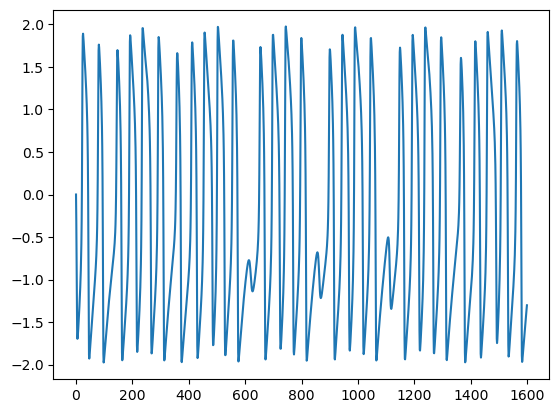

In [4]:
plt.figure()
plt.plot(nature.x0[0, :])

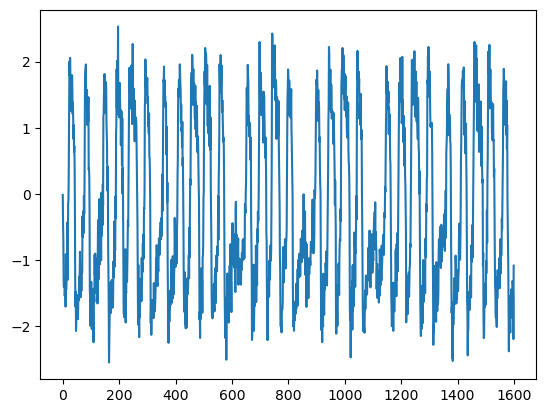

In [5]:
plt.figure()
plt.plot(nature.y[0,:])

## Modifying the FN model for parameter tracking
With this class we can flexibly track the parameers that we want

In [6]:
class FNModel_with_parameter_tracking(ukf_voss.FNModel):
	def __init__(self, a=0.7, b=0.8, c=3., Q_par=0.015, Q_var=np.array((1.,)), R=1., track_a=False, track_b=False, track_c=False):
		super(FNModel_with_parameter_tracking, self).__init__(a, b, c, Q_par, Q_var, R)
		self.track_a = track_a
		self.track_b = track_b
		self.track_c = track_c

	def n_params(self):
		return 1 + int(self.track_a) + int(self.track_b) + int(self.track_c)

	def obs_g_model(self, x):
		return x[self.n_params(), :]

	def f_model(self, x, p):
		a, b, c = self.a, self.b, self.c

		n_p = 1; 
		if self.track_a:
			a = p[n_p, :]
			n_p += 1

		if self.track_b:
			b = p[n_p, :]
			n_p += 1

		if self.track_c:
			c = p[n_p, :]

		x = np.atleast_2d(x)
		# return np.array([c * (x[1,:] + x[0,:] - x[0,:]**3 / 3 + p), -(x[0,:] - a + b * x[1,:]) / c])
		rr = [np.atleast_2d(c * (x[1, :] + x[0, :] - x[0, :] ** 3 / 3 + p[0, :])),
			  np.atleast_2d(-(x[0, :] - a + b * x[1, :]) / c)]
		# print(rr)
		return np.vstack(rr)



### Track c

In [7]:
# define the model
q = 0.015
Q_par = np.diag((q, q))
Q_var0 = np.diag((nature.R, nature.R))
#Define the model used for the Kalman filtering
fn_model = FNModel_with_parameter_tracking(Q_par=Q_par, Q_var=Q_var0, R=nature.R,track_c=True)

In [8]:
#Send to the kalman filter the model we want
uk_filter = ukf_voss.UKFVoss(model=fn_model, ll=1600)

In [9]:
init = np.array([0.,1, nature.y[0,0], 0.]) #Initial conditions for the KF (p,x) so if you change the number of parameters you are tracking you need to change this (by default we allways track the current)
#Run the Kalman filter simulation
x_hat0, Pxx0, Ks0, errors0 = uk_filter.filter(nature.y, initial_condition=init)

100%|██████████| 1599/1599 [00:07<00:00, 226.23it/s]


In [10]:
def summary_plots():
	plt.figure()
	dq=fn_model.n_params()
	plt.subplot(2, 1, 1)
	plt.plot(nature.y.ravel(), 'bd', markeredgecolor='blue', markerfacecolor='blue', markersize=3)
	plt.plot(nature.x0[0, :], color='black', linewidth=2)
	plt.plot(x_hat0[dq + 0, :], 'r', linewidth=2)
	plt.xlabel('t')
	plt.ylabel('x_1, y')
	plt.title('(a)')
	plt.legend(('observations', 'real x_1', 'estimated x_1'))
	plt.subplot(2, 1, 2)
	plt.plot(nature.x0[1, :], color='black', linewidth=2)
	plt.plot(x_hat0[dq + 1, :], 'r', linewidth=2)
	plt.plot(nature.p[0, :], color='black', linewidth=2)
	colors = 'b', 'g', 'y', 'b'
	for i in range(dq):
		plt.plot(x_hat0[i, :], colors[i], linewidth=2)
	for i in range(dq):
		plt.plot(x_hat0[i, :] + errors0[i, :], colors[i])
	for i in range(dq):
		plt.plot(x_hat0[i, :] - errors0[i, :], colors[i])

	plt.xlabel('t')
	plt.ylabel('z, estimated z, x_2, estimated x_2')
	plt.title('(b)')


	plt.tight_layout()

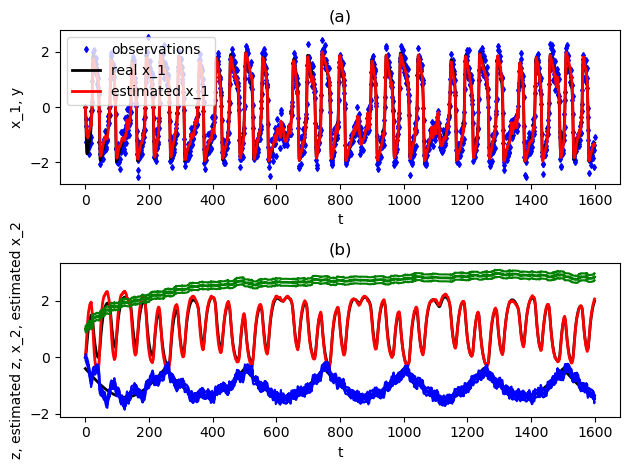

In [11]:
summary_plots()

We assume a_model, b_model = a_nature, b_nature (Also try different and see what happens) \
Graph (a): \
Estimate of the first hidden variable based only on the blue observations \
Graph (b): \
In red estimate of the second hidden state \
In blue the estimate of the current (note we never "see" the actual current values) \
In green the estimate of the parameter c (Starts on our initial guess c=1) \

## Track a

In [13]:
# define the model
q = 0.015
Q_par = np.diag((q, q))
Q_var0 = np.diag((nature.R, nature.R))
#Define the model used for the Kalman filtering
fn_model_ta = FNModel_with_parameter_tracking(Q_par=Q_par, Q_var=Q_var0, R=nature.R,track_a=True)

#Send to the kalman filter the model we want
uk_filter = ukf_voss.UKFVoss(model=fn_model_ta, ll=1600)

In [14]:
init = np.array([0.,1, nature.y[0,0], 0.]) #Initial conditions for the KF (p,x) so if you change the number of parameters you are tracking you need to change this (by default we allways track the current)
#Run the Kalman filter simulation
x_hat0, Pxx0, Ks0, errors0 = uk_filter.filter(nature.y, initial_condition=init)

100%|██████████| 1599/1599 [00:07<00:00, 226.93it/s]


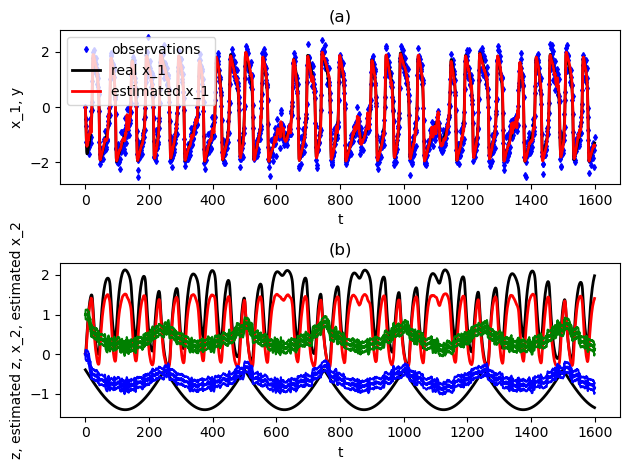

In [15]:
summary_plots()

## Track b

In [16]:
# define the model
q = 0.015
Q_par = np.diag((q, q))
Q_var0 = np.diag((nature.R, nature.R))
#Define the model used for the Kalman filtering
fn_model_tb = FNModel_with_parameter_tracking(Q_par=Q_par, Q_var=Q_var0, R=nature.R,track_b=True)

#Send to the kalman filter the model we want
uk_filter = ukf_voss.UKFVoss(model=fn_model_tb, ll=1600)

In [17]:
init = np.array([0.,1, nature.y[0,0], 0.]) #Initial conditions for the KF (p,x) so if you change the number of parameters you are tracking you need to change this (by default we allways track the current)
#Run the Kalman filter simulation
x_hat0, Pxx0, Ks0, errors0 = uk_filter.filter(nature.y, initial_condition=init)

100%|██████████| 1599/1599 [00:06<00:00, 230.04it/s]


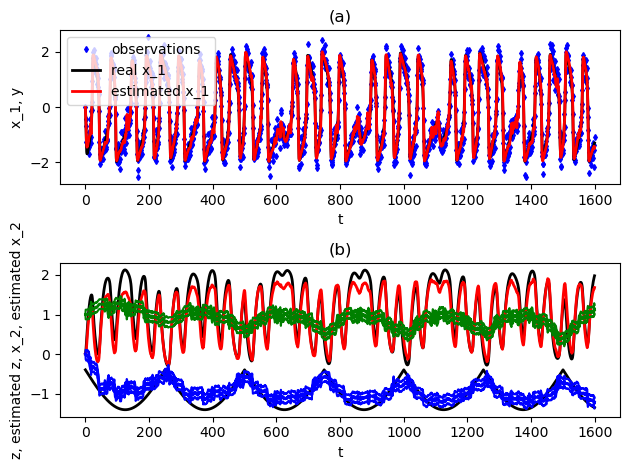

In [18]:
summary_plots()

## Track a,b

In [23]:
# define the model
q = 0.015
Q_par = np.diag((q, q))
Q_var0 = np.diag((nature.R, nature.R))
#Define the model used for the Kalman filtering
fn_model_tab = FNModel_with_parameter_tracking(Q_par=Q_par, Q_var=Q_var0, R=nature.R,track_a=True,track_b=True)

#Send to the kalman filter the model we want
uk_filter = ukf_voss.UKFVoss(model=fn_model_tab, ll=1600)

In [33]:
init = np.array([0.,1, nature.y[0,0], 0.,0.])
init.shape

(5,)

In [40]:
uk_filter.Q
#fn_model_tab.Q_par
#fn_model_tab.Q_var

array([[0.015     , 0.        , 0.        , 0.        ],
       [0.        , 0.015     , 0.        , 0.        ],
       [0.        , 0.        , 0.06654445, 0.        ],
       [0.        , 0.        , 0.        , 0.06654445]])

In [34]:
init = np.array([0.,1, nature.y[0,0], 0.,0.]) #Initial conditions for the KF (p,x) so if you change the number of parameters you are tracking you need to change this (by default we allways track the current)
#Run the Kalman filter simulation
x_hat0, Pxx0, Ks0, errors0 = uk_filter.filter(nature.y, initial_condition=init)

ValueError: could not broadcast input array from shape (4,4) into shape (5,5)

(1, 1600)

In [ ]:
summary_plots()